<a href="https://colab.research.google.com/github/ThiPi93/BigDataSenacNI/blob/main/Meu_codigo_aula16_bigdata_uc2_07_01_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import polars as pl
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


In [2]:
import polars as pl

pl.scan_csv(
    "/content/title.basics.tsv",
    separator="\t",
    null_values="\\N",
    encoding="utf8",
    quote_char=None,          # ← ESSENCIAL
    truncate_ragged_lines=True,
    ignore_errors=True,
    infer_schema_length=200_000
).sink_parquet(
    "/content/title_basics_POLARS.parquet"
)


In [3]:
import polars as pl

pl.scan_csv(
    "/content/title.ratings.tsv",
    separator="\t",
    null_values="\\N",
    encoding="utf8",
    quote_char=None,          # ← ESSENCIAL
    truncate_ragged_lines=True,
    ignore_errors=True,
    infer_schema_length=50_000
).sink_parquet(
    "/content/title_ratings_POLARS.parquet"
)


In [4]:
import polars as pl

# Leitura dos arquivos parquet do IMDb
titles = pl.scan_parquet("/content/title_basics_POLARS.parquet")
ratings = pl.scan_parquet("/content/title_ratings_POLARS.parquet")

# DataFrame inicial do projeto
inicial = (
    titles
    .join(ratings, on="tconst", how="inner")
    .select([
        "tconst",
        "primaryTitle",
        "titleType",
        "startYear",
        "runtimeMinutes",
        "averageRating",
        "numVotes"
    ])
    # Garantir tipos numéricos corretos
    .with_columns([
        pl.col("runtimeMinutes").cast(pl.Int32),
        pl.col("averageRating").cast(pl.Float64),
        pl.col("numVotes").cast(pl.Int32)
    ])
)

# Visualização
display(inicial.collect().head())


tconst,primaryTitle,titleType,startYear,runtimeMinutes,averageRating,numVotes
str,str,str,i64,i32,f64,i32
"""tt0000001""","""Carmencita""","""short""",1894,1,5.7,2185
"""tt0000002""","""Le clown et ses chiens""","""short""",1892,5,5.5,306
"""tt0000003""","""Poor Pierrot""","""short""",1892,5,6.4,2270
"""tt0000004""","""Un bon bock""","""short""",1892,12,5.2,196
"""tt0000005""","""Blacksmith Scene""","""short""",1893,1,6.2,3010


Dados para plotagem:
   startYear  nota_media
0       1894    5.200000
1       1897    4.650000
2       1898    2.283333
3       1899    2.325000
4       1900    3.371429


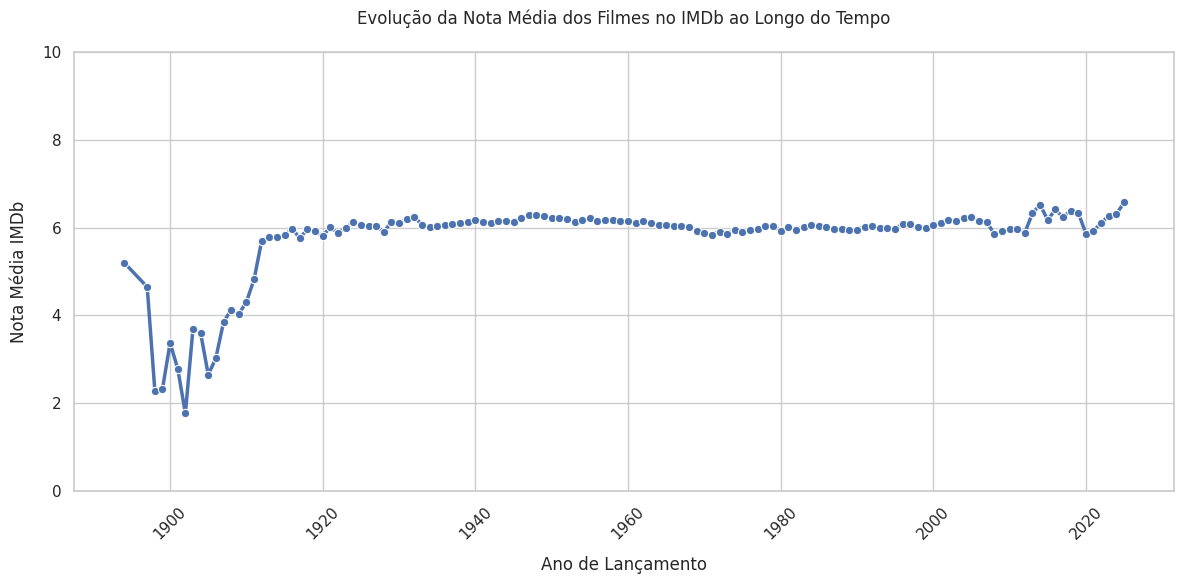

In [5]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Agregar por ano de lançamento
df_agrupado = (
    inicial
    .filter(
        (pl.col("titleType") == "movie") &
        (pl.col("startYear").is_not_null()) &
        (pl.col("averageRating").is_not_null())
    )
    .group_by("startYear")
    .agg(
        pl.col("averageRating").mean().alias("nota_media")
    )
    .sort("startYear")
    .collect()
)

# 2. Converter para Pandas
df_plot = df_agrupado.to_pandas()

# Conferência dos dados
print("Dados para plotagem:")
print(df_plot.head())

# 3. Configuração do estilo
sns.set_theme(style="whitegrid")

# 4. Criar figura e eixo
fig, ax = plt.subplots(figsize=(12, 6))

# 5. Plotar a série temporal
sns.lineplot(
    data=df_plot,
    x="startYear",
    y="nota_media",
    ax=ax,
    marker="o",
    linewidth=2.5
)

# 6. Ajustes visuais
ax.set_title("Evolução da Nota Média dos Filmes no IMDb ao Longo do Tempo", pad=20)
ax.set_xlabel("Ano de Lançamento", labelpad=10)
ax.set_ylabel("Nota Média IMDb", labelpad=10)
ax.set_ylim(0, 10)  # Escala natural do IMDb
ax.tick_params(axis="x", rotation=45)

# 7. Layout final
plt.tight_layout()
plt.show()


###Preparação dos Dados para Análise de Correlação e Regressão

Para investigar a relação entre a duração dos filmes e sua avaliação no IMDb, os dados foram organizados da seguinte forma:

- Variável Independente (X):
Duração do filme em minutos (runtimeMinutes) — representa o tempo total da obra audiovisual.

- Variável Dependente (Y):
Nota média no IMDb (averageRating) — expressa a avaliação atribuída pelo público.

Antes da análise, foram considerados apenas:

- filmes (titleType = "movie"),

- registros com duração e nota válidas (não nulas),

- valores dentro de limites plausíveis para evitar distorções causadas por obras excepcionalmente longas.

Objetivo analítico:
Verificar se existe associação estatística entre a minutagem de um filme e sua nota no IMDb, identificando se filmes mais longos tendem a receber avaliações maiores, menores ou semelhantes aos filmes mais curtos.

In [8]:
import polars as pl

# 1. Garantir tipos corretos
df_reg = (
    inicial
    .filter(
        (pl.col("titleType") == "movie") &
        (pl.col("runtimeMinutes").is_not_null()) &
        (pl.col("averageRating").is_not_null())
    )
    .with_columns([
        pl.col("runtimeMinutes").cast(pl.Float64).alias("DURACAO_MIN"),
        pl.col("averageRating").cast(pl.Float64).alias("NOTA_IMDB")
    ])
)

# 2. Selecionar apenas variáveis da análise
df_reg_final = df_reg.select([
    "DURACAO_MIN",   # Variável Independente (X)
    "NOTA_IMDB"      # Variável Dependente (Y)
])

# 3. Verificar os dados preparados
display(df_reg_final.head())


df_reg_final.select(
    pl.corr("DURACAO_MIN", "NOTA_IMDB", method="pearson").alias("Pearson"),
    pl.corr("DURACAO_MIN", "NOTA_IMDB", method="spearman").alias("Spearman")
).collect()


Pearson,Spearman
f64,f64
0.078469,0.128593


Modelo de Regressão Linear (≤ 350 minutos)
Equação: NOTA_IMDB = 0.0063 × DURACAO_MIN + 5.4700
R²: 0.0159
MSE: 1.3820


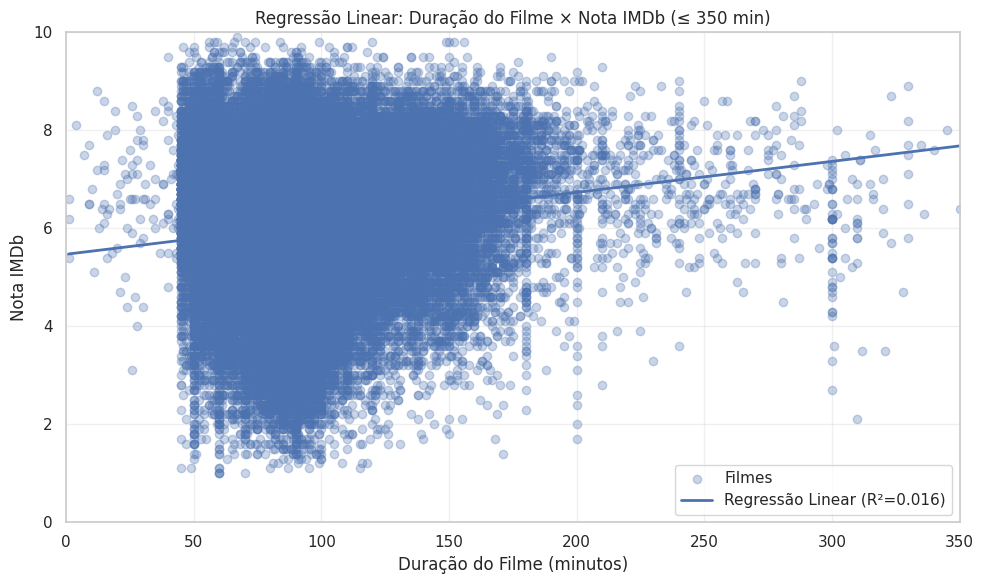

In [11]:
# =========================
# REGRESSÃO LINEAR
# Duração do Filme × Nota IMDb
# (com corte em 350 minutos)
# =========================

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. Filtrar filmes com duração até 350 minutos
df_modelo = (
    df_reg_final
    .filter(pl.col("DURACAO_MIN") <= 350)
    .select(["DURACAO_MIN", "NOTA_IMDB"])
    .drop_nulls()
    .collect()
)

# 2. Preparar variáveis para o modelo
X = df_modelo["DURACAO_MIN"].to_numpy().reshape(-1, 1)
y = df_modelo["NOTA_IMDB"].to_numpy()

# 3. Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Coeficientes
inclinacao = modelo.coef_[0]
intercepto = modelo.intercept_

# 4. Previsões
y_pred = modelo.predict(X)

# 5. Avaliação
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print("Modelo de Regressão Linear (≤ 350 minutos)")
print(f"Equação: NOTA_IMDB = {inclinacao:.4f} × DURACAO_MIN + {intercepto:.4f}")
print(f"R²: {r2:.4f}")
print(f"MSE: {mse:.4f}")

# 6. Visualização
plt.figure(figsize=(10, 6))

# Dados reais
plt.scatter(X, y, alpha=0.3, label="Filmes")

# Linha de regressão (ordenada)
ordem = np.argsort(X.flatten())
plt.plot(
    X.flatten()[ordem],
    y_pred[ordem],
    linewidth=2,
    label=f"Regressão Linear (R²={r2:.3f})"
)

# Configurações do gráfico
plt.title("Regressão Linear: Duração do Filme × Nota IMDb (≤ 350 min)")
plt.xlabel("Duração do Filme (minutos)")
plt.ylabel("Nota IMDb")
plt.xlim(0, 350)
plt.ylim(0, 10)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()



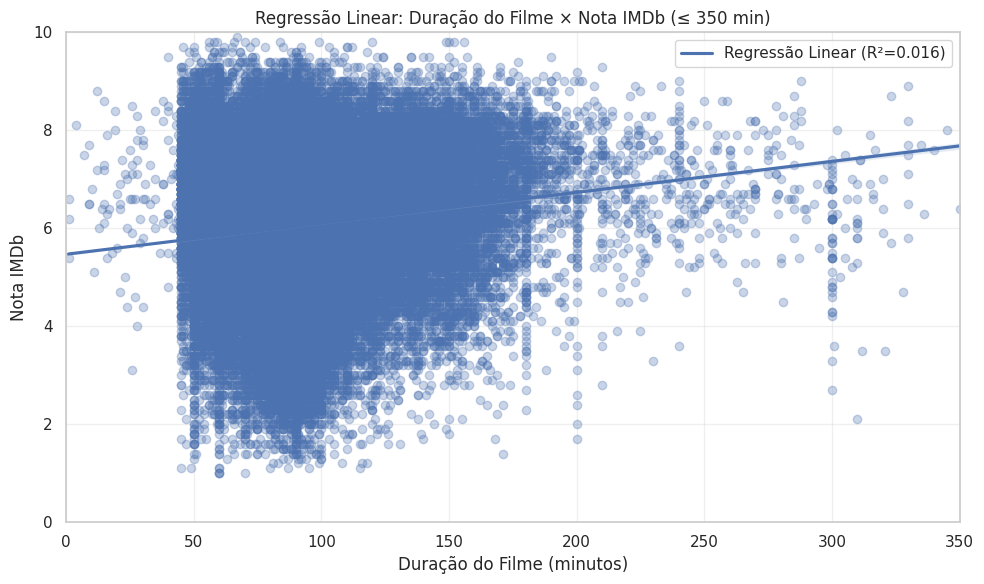

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfico de regressão com intervalo de confiança (95%)
plt.figure(figsize=(10, 6))

sns.regplot(
    x=X.flatten(),          # Duração do filme (minutos)
    y=y,                    # Nota IMDb
    ci=95,                  # Intervalo de confiança de 95%
    scatter_kws={'alpha': 0.3},
    line_kws={
        'label': f'Regressão Linear (R²={r2:.3f})'
    }
)

# Configurações do gráfico
plt.title('Regressão Linear: Duração do Filme × Nota IMDb (≤ 350 min)')
plt.xlabel('Duração do Filme (minutos)')
plt.ylabel('Nota IMDb')
plt.xlim(0, 350)
plt.ylim(0, 10)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()
